# Experiment 1 — headline benchmark (PD)

5-fold CV on the 14 PD datasets. For each reported quantity — **AUC**, **Brier**, **F1**, **training time**, and the **per-dataset rank (by AUC)** — the same three views: the dataset x method **matrix** (best column left), a **bar** chart per method, and a **box** plot of the spread across datasets. Then the **HPO effect on AUC** and the **performance vs time** frontier.

Figures → `figures/experiment1/pd/` (wiped on rerun).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, median_time_bars, rank_heatmap, rank_boxplots,
    hpo_improvement_bars, runtime_performance_scatter,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/pd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\pd


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd')          # NO_HPO
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', hpo_mode=None)
print(f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

34 methods x 14 datasets


## AUC

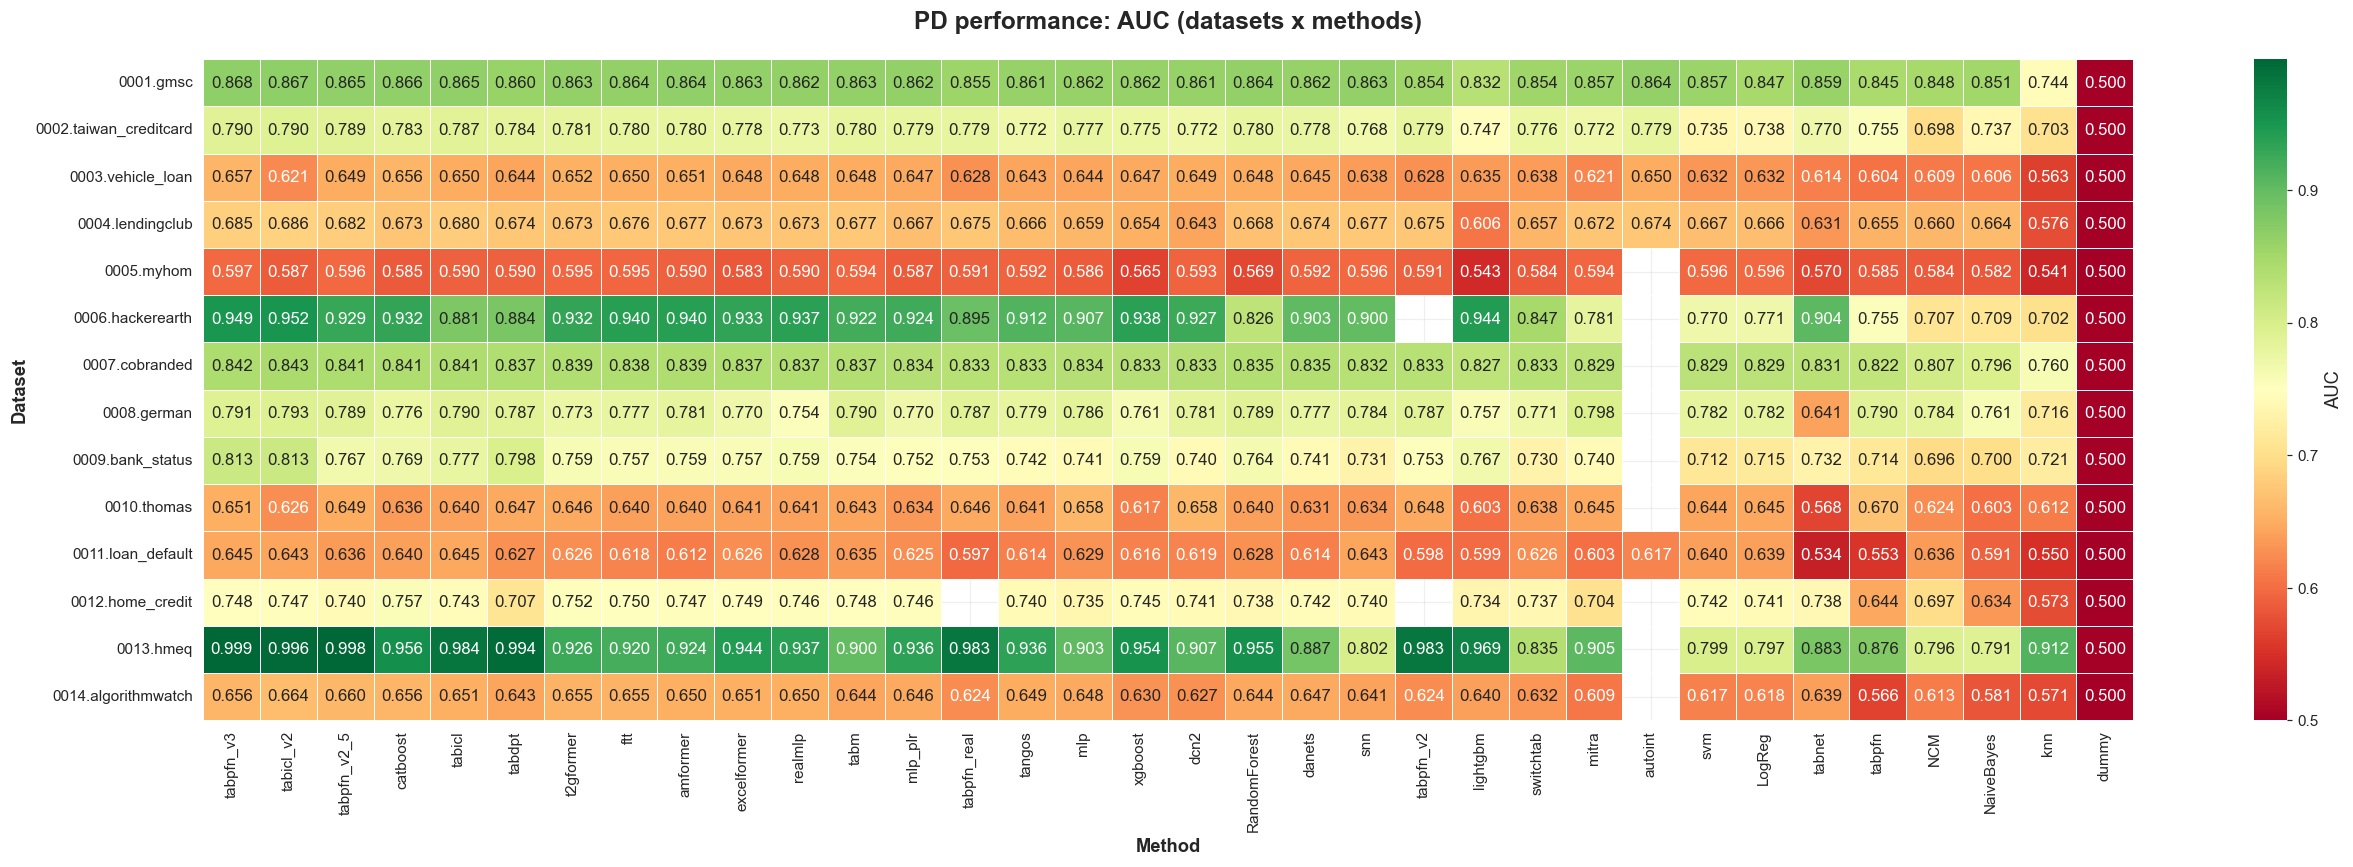

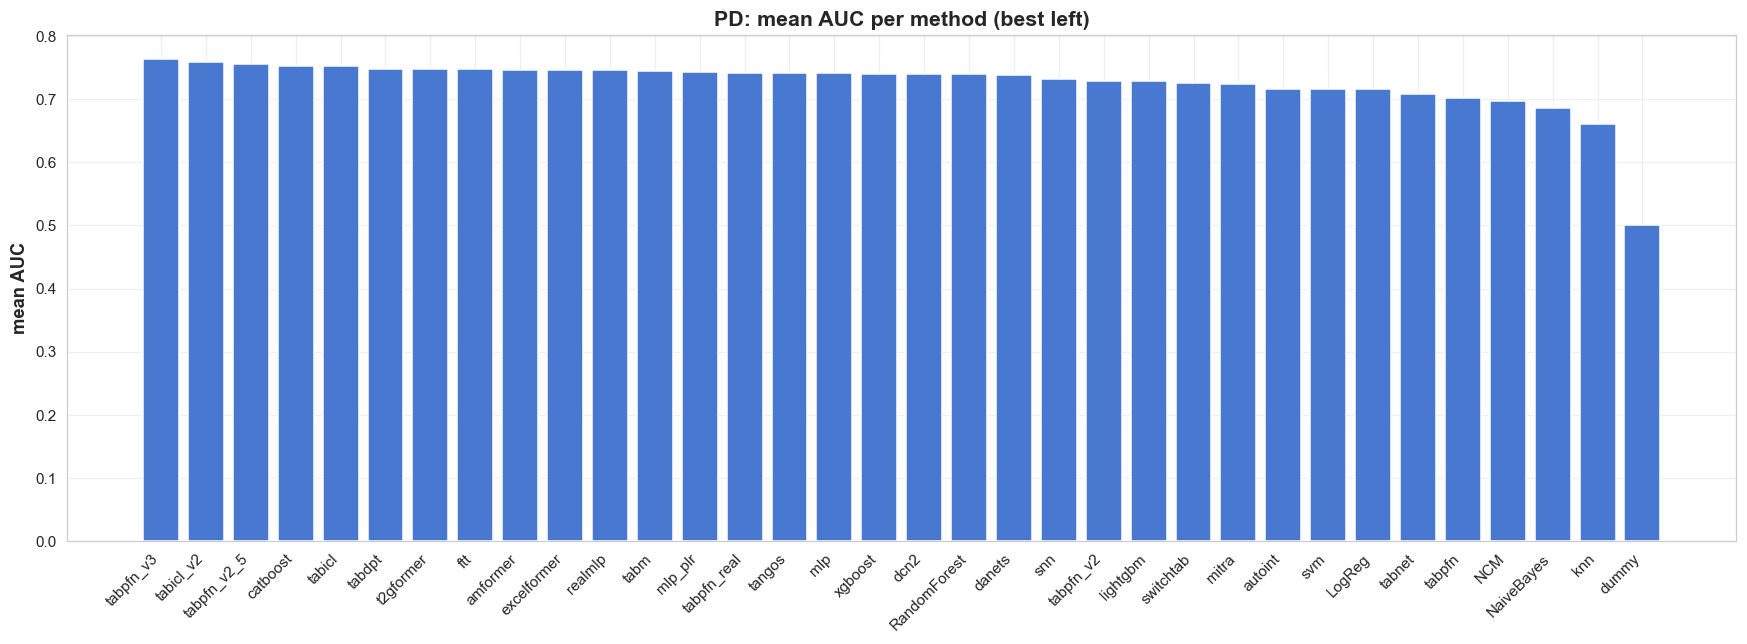

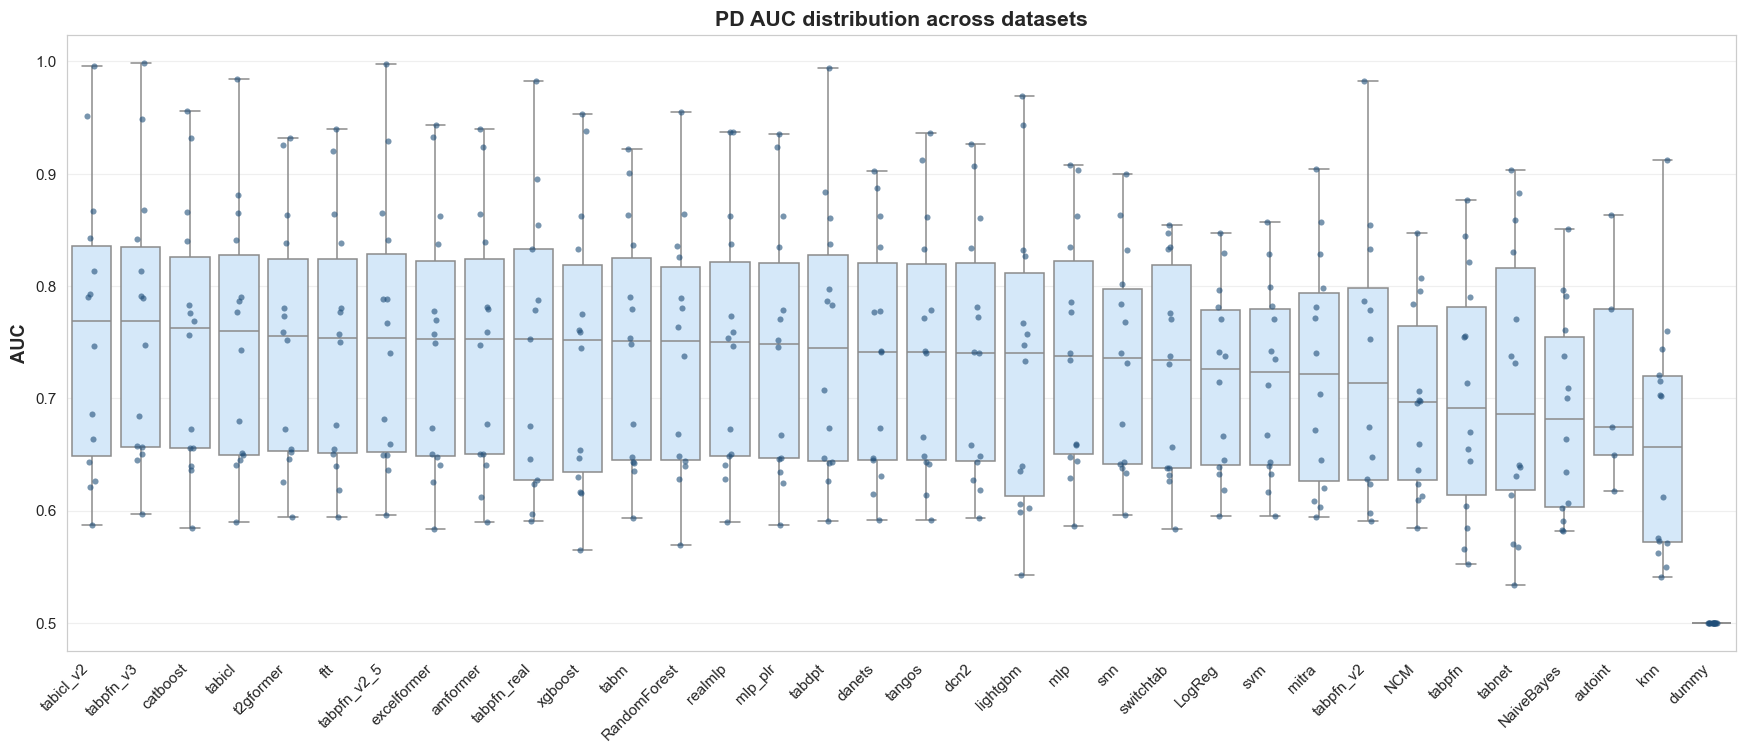

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_auc.pdf')

In [3]:
performance_heatmap(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)

## Brier score (lower is better)

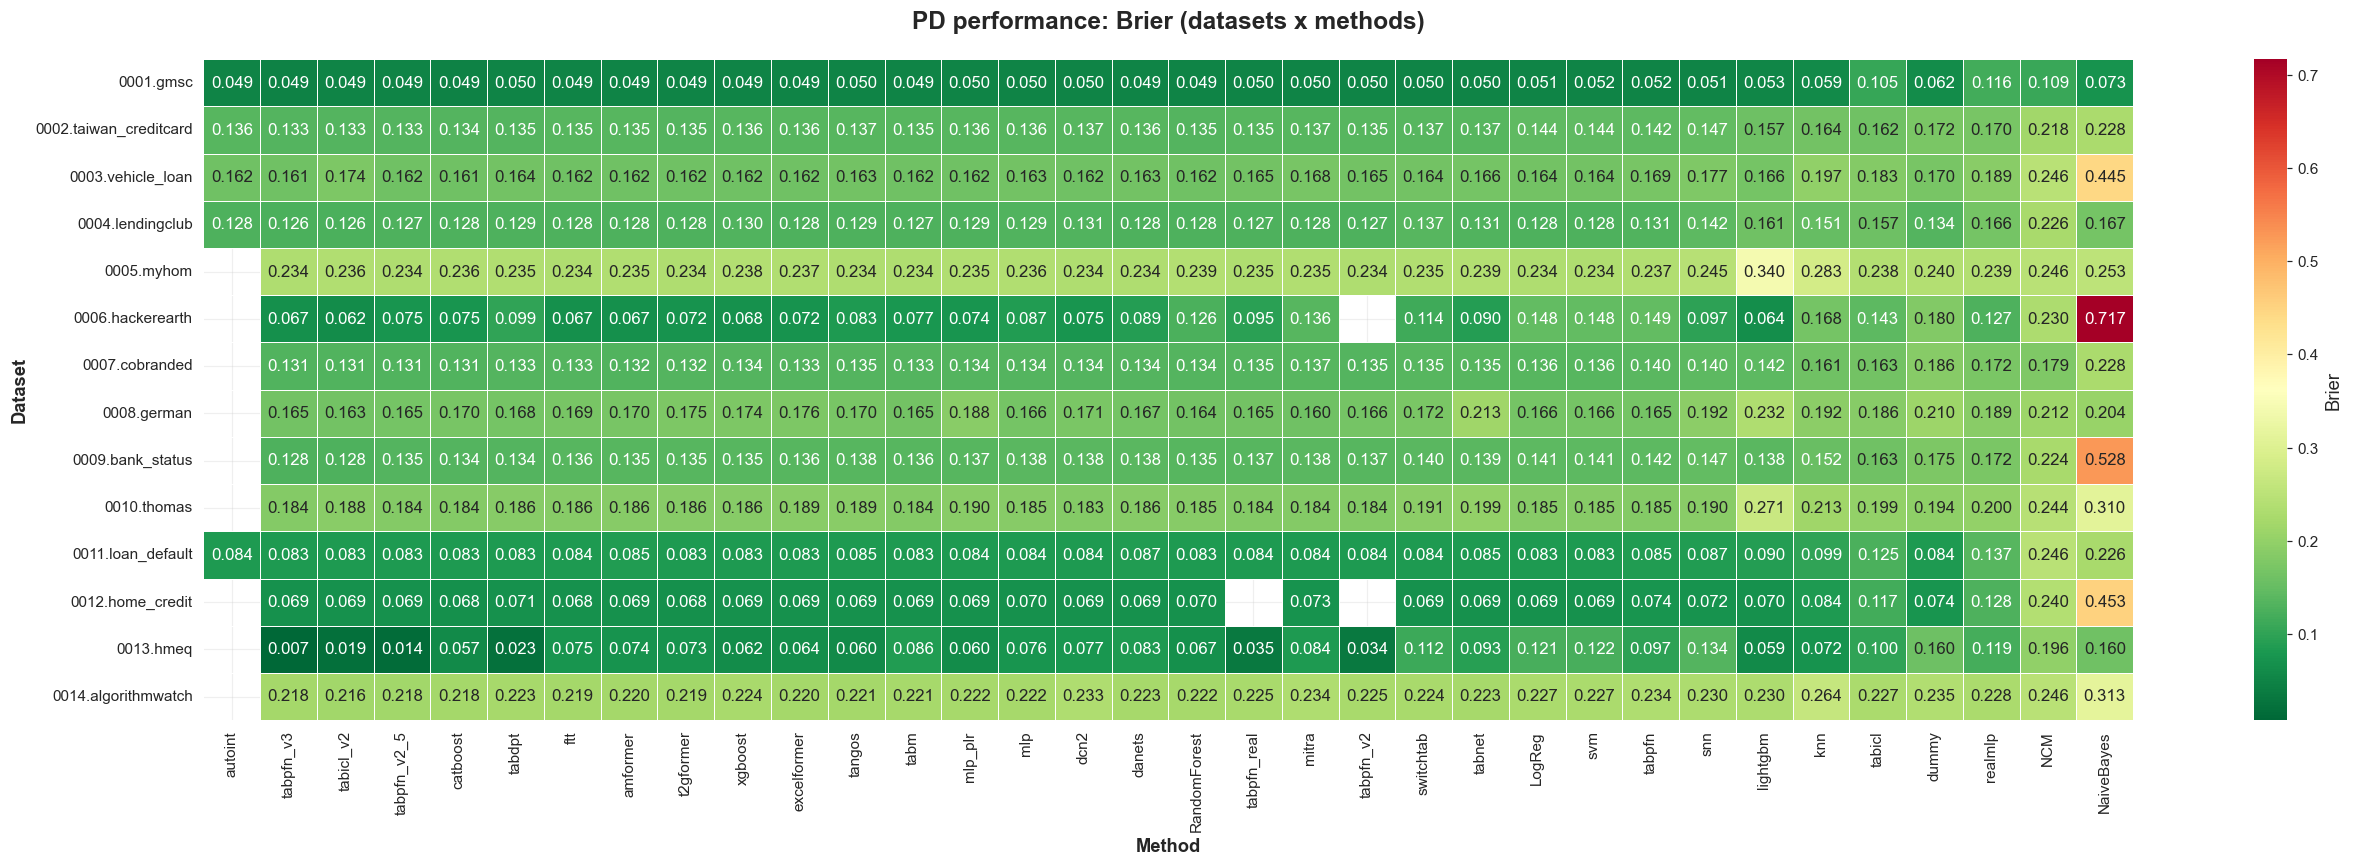

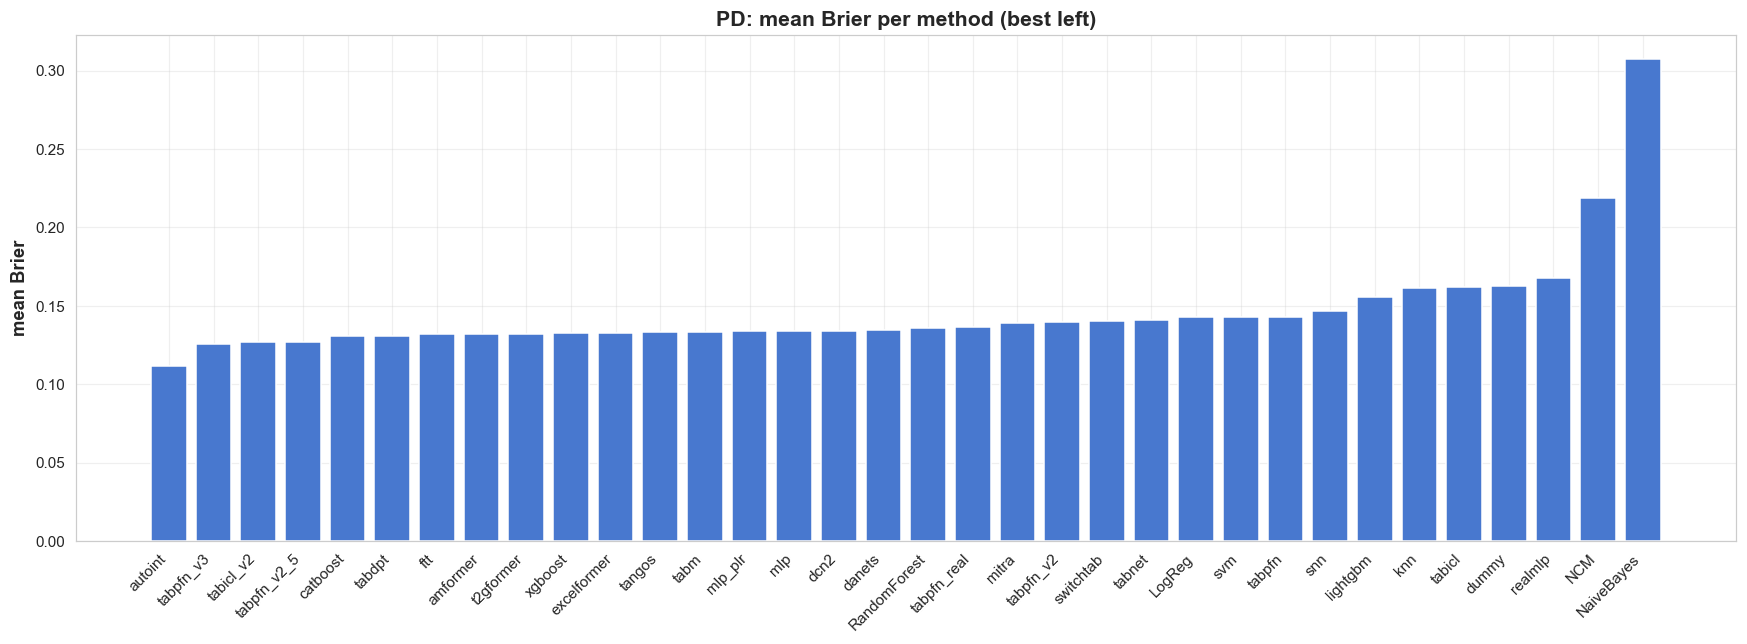

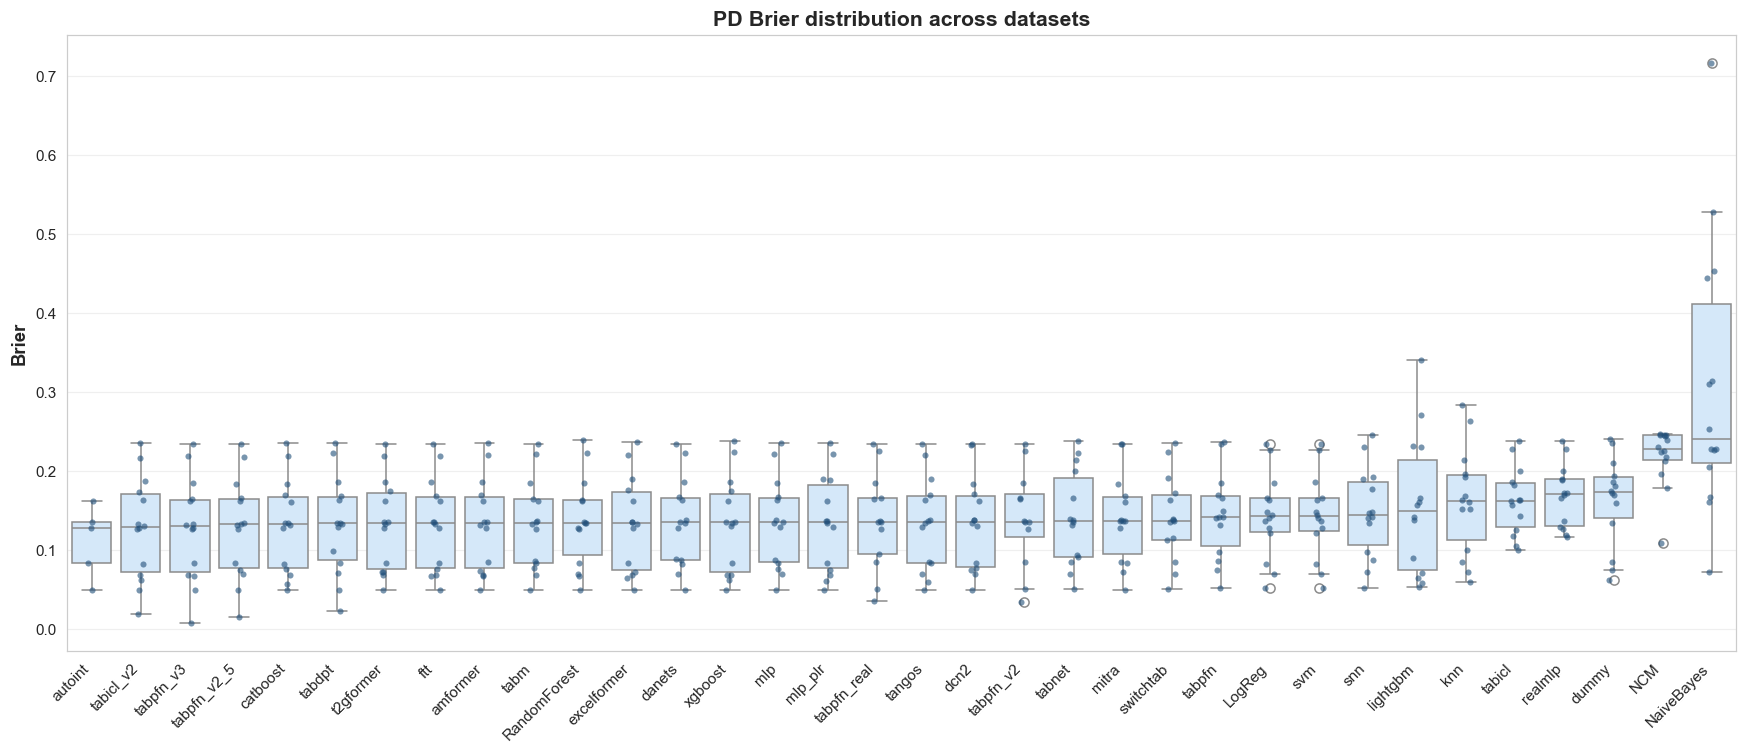

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_brier.pdf')

In [4]:
performance_heatmap(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_bars(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_boxplots(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)

## F1

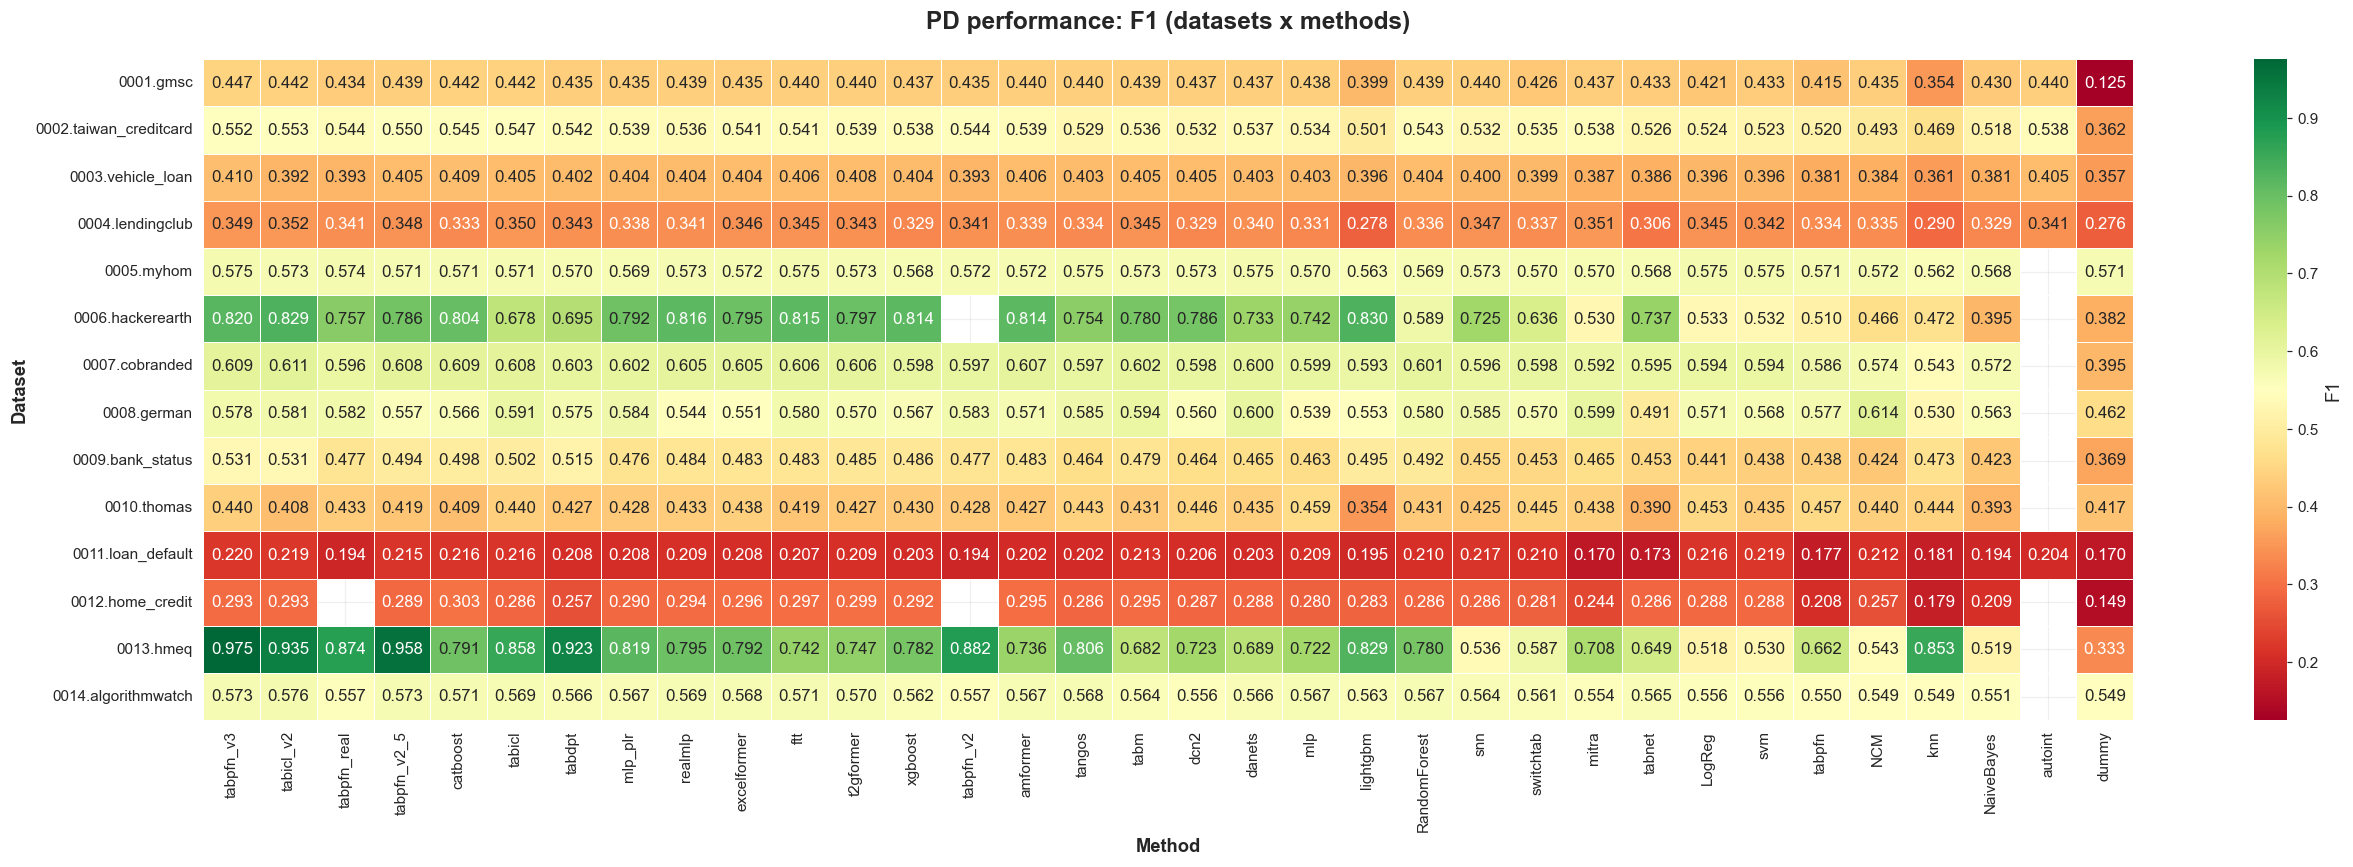

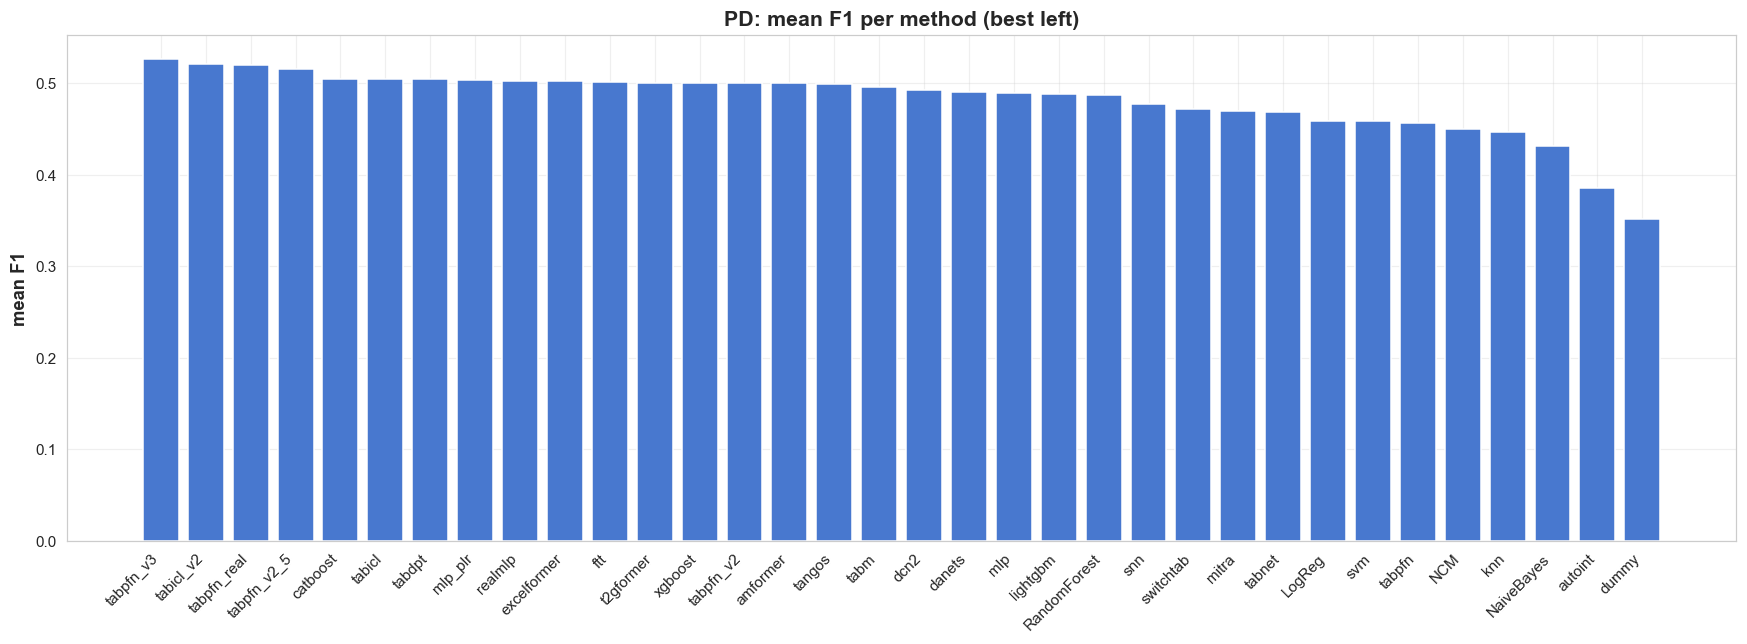

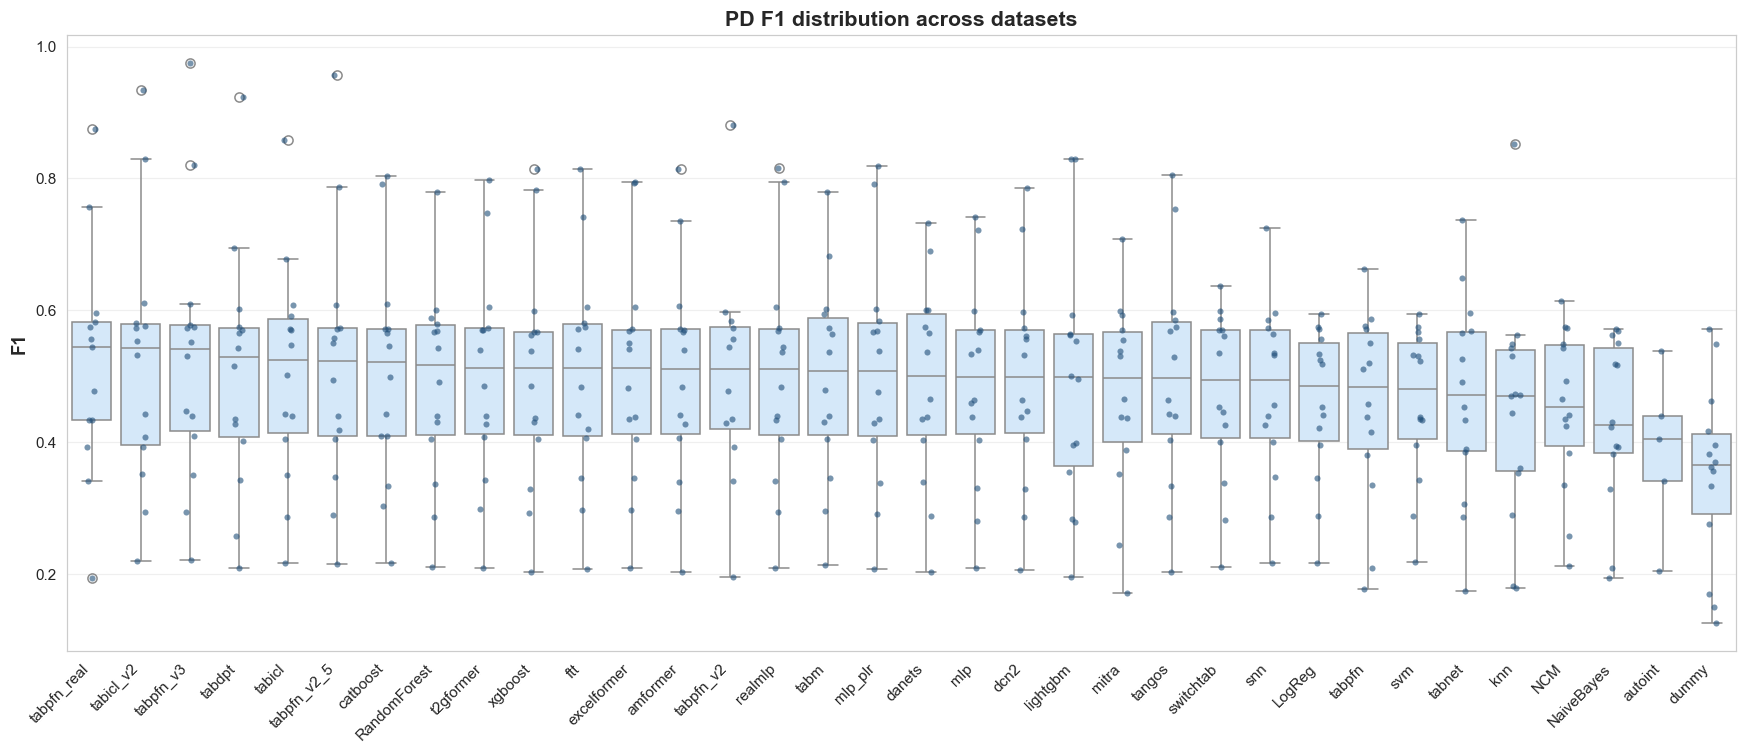

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_f1.pdf')

In [5]:
performance_heatmap(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)

## Training time (seconds per fold; lower is better)

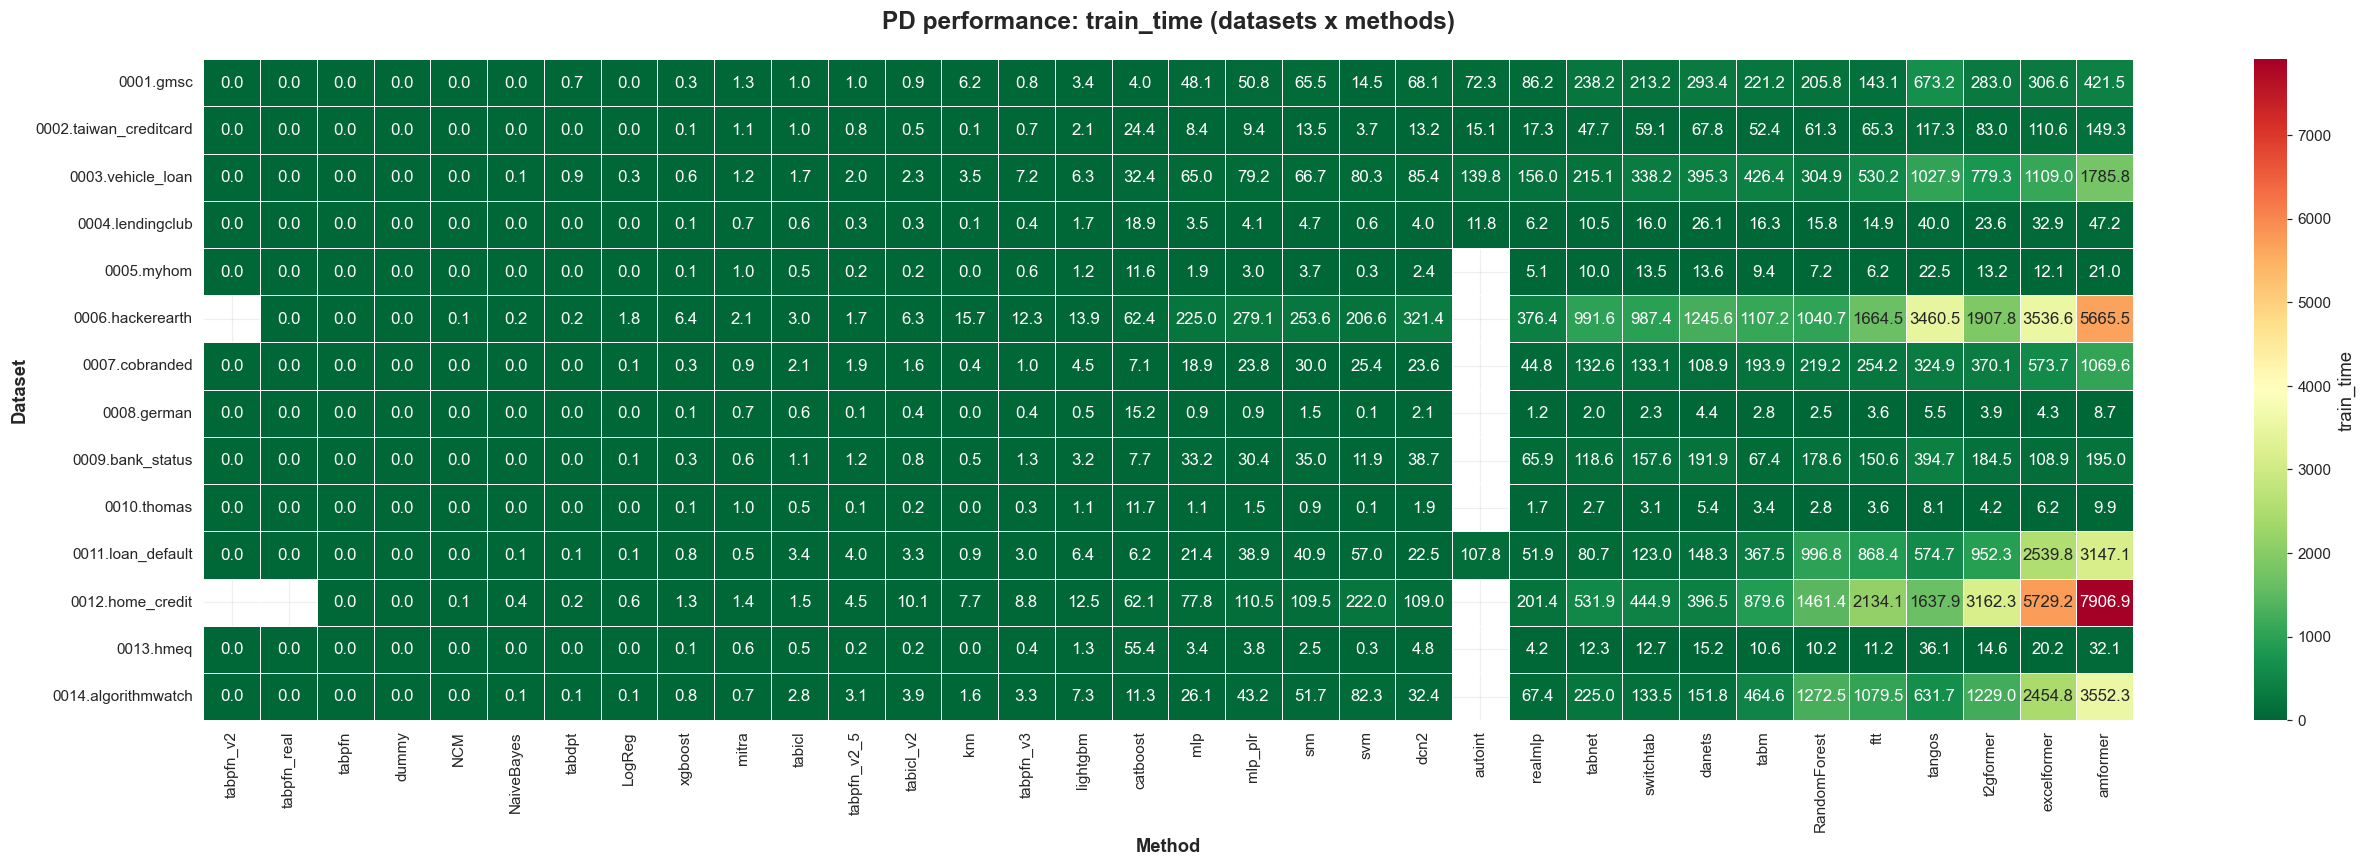

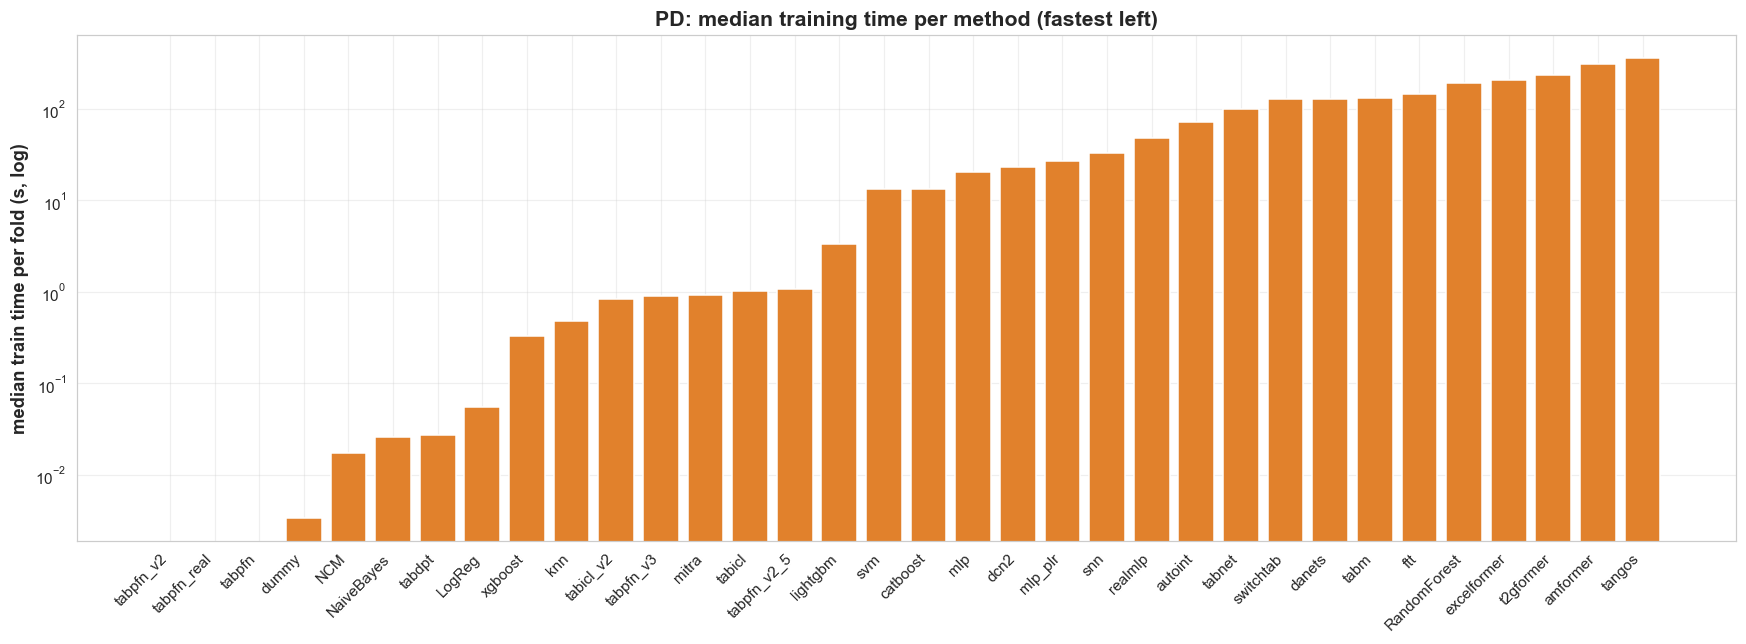

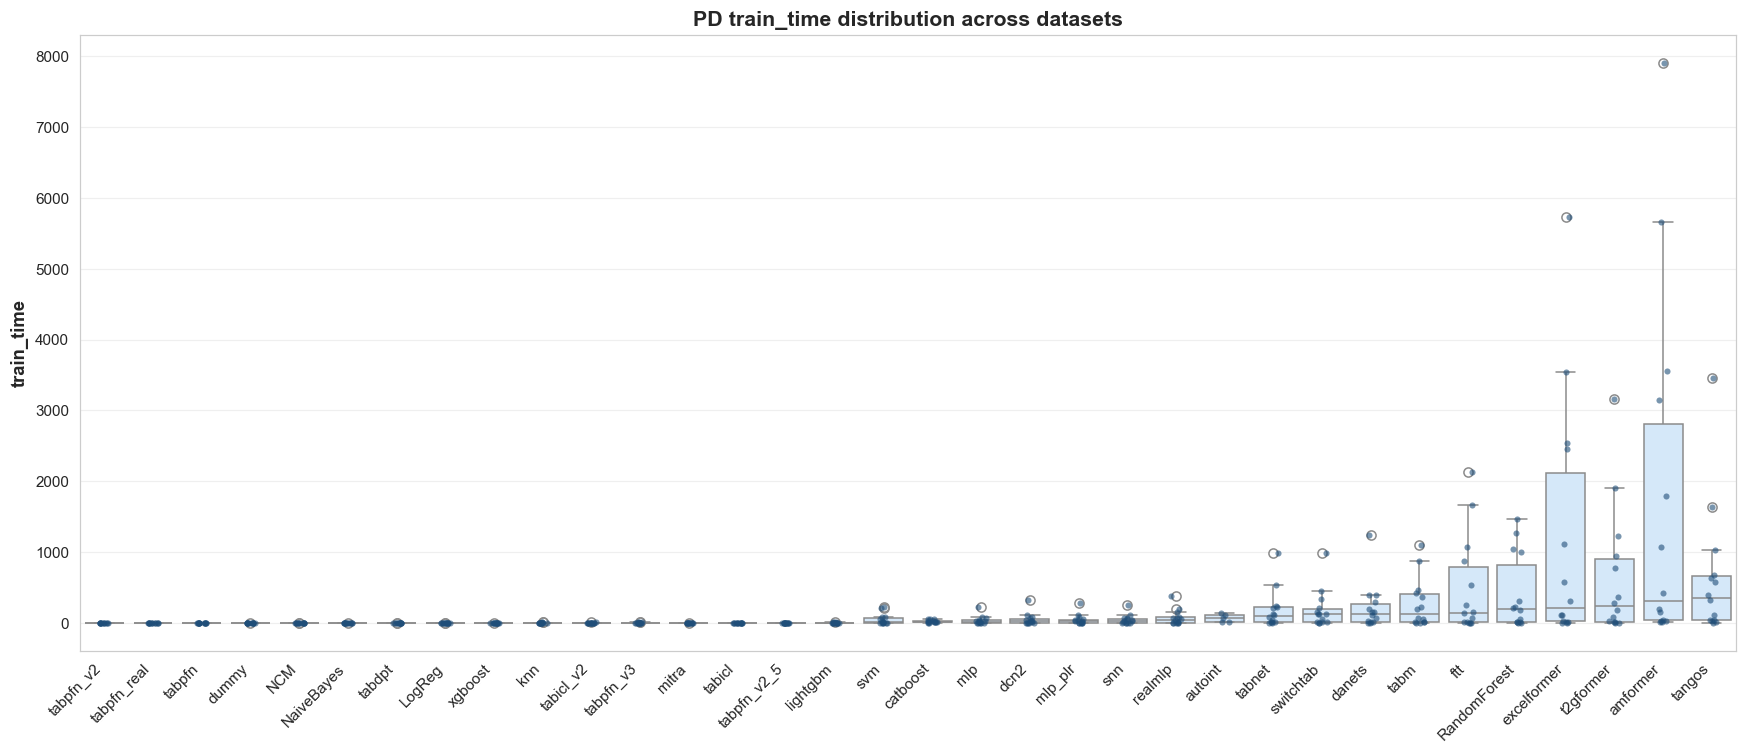

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_train_time.pdf')

In [6]:
performance_heatmap(df, 'train_time', task_name='PD', higher_is_better=False, fmt='.1f', out_dir=FIGURES_DIR)
median_time_bars(df, task_name='PD', out_dir=FIGURES_DIR)
metric_boxplots(df, 'train_time', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)

## Rank by AUC (1 = best on that dataset)

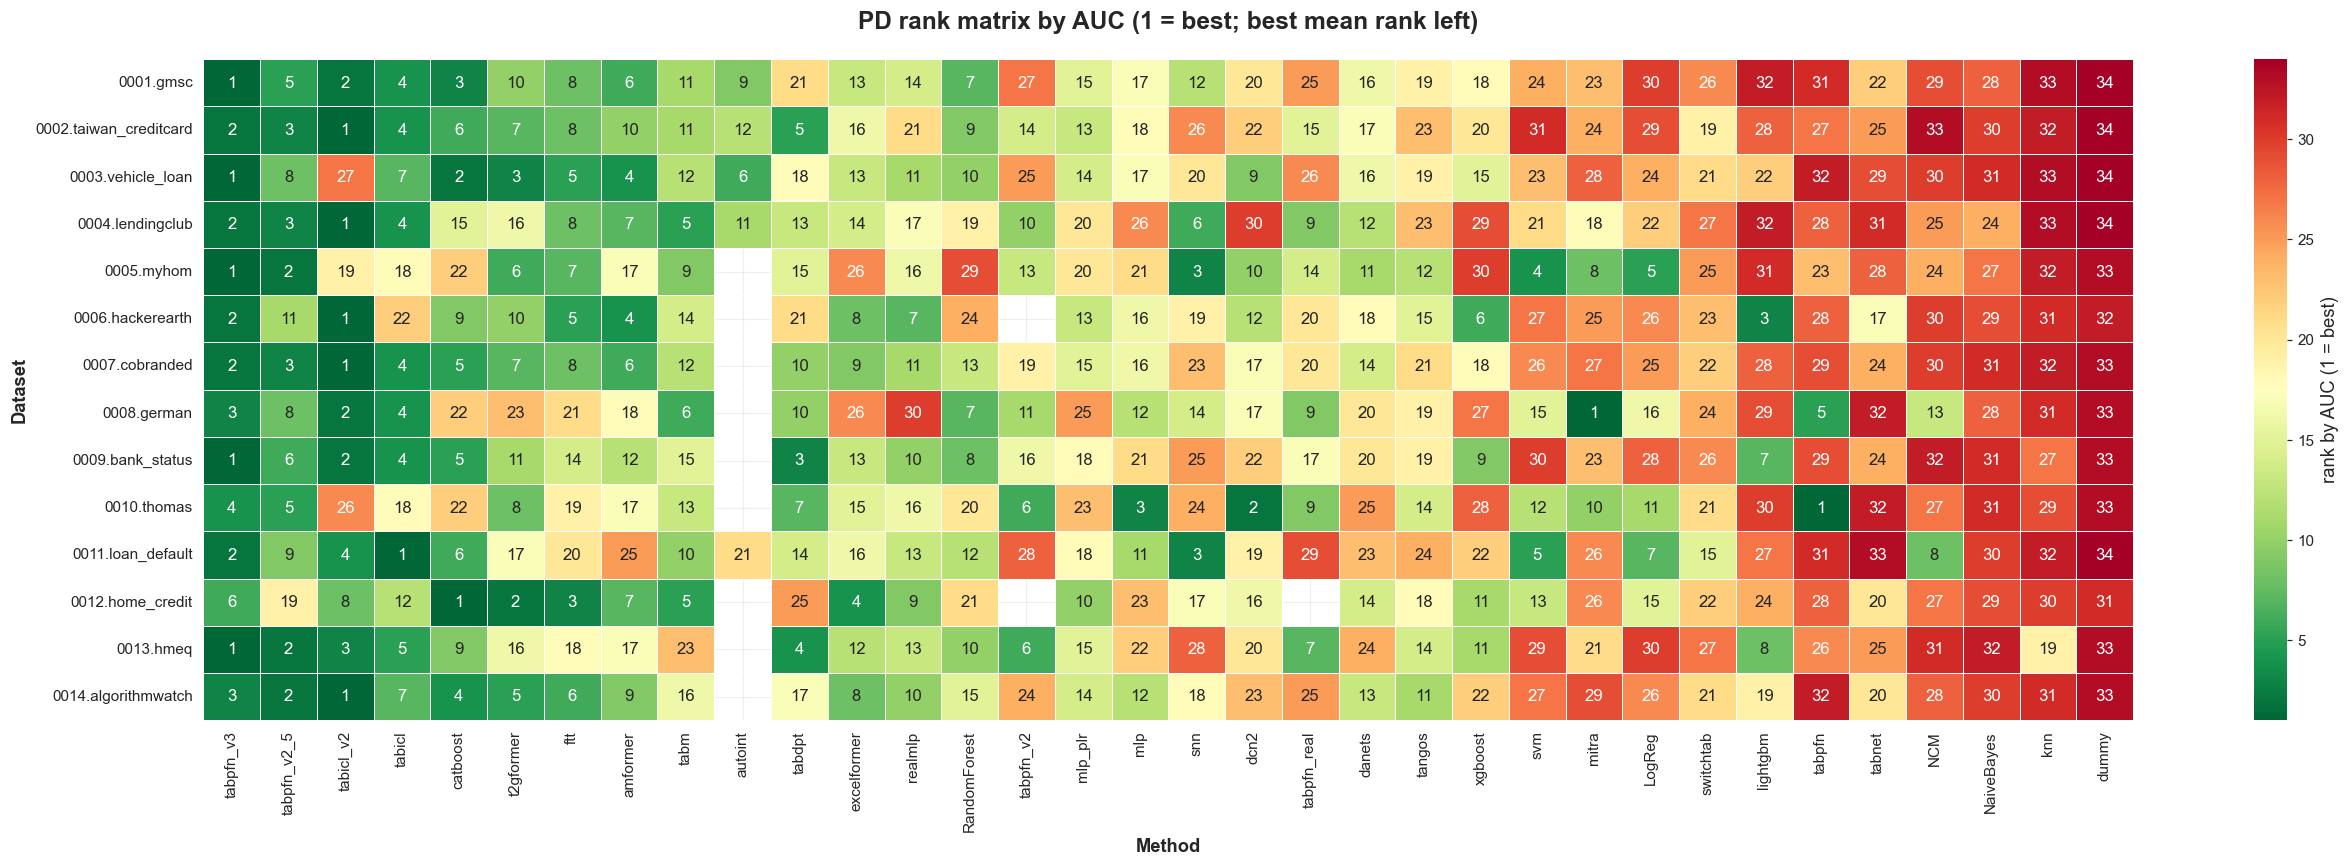

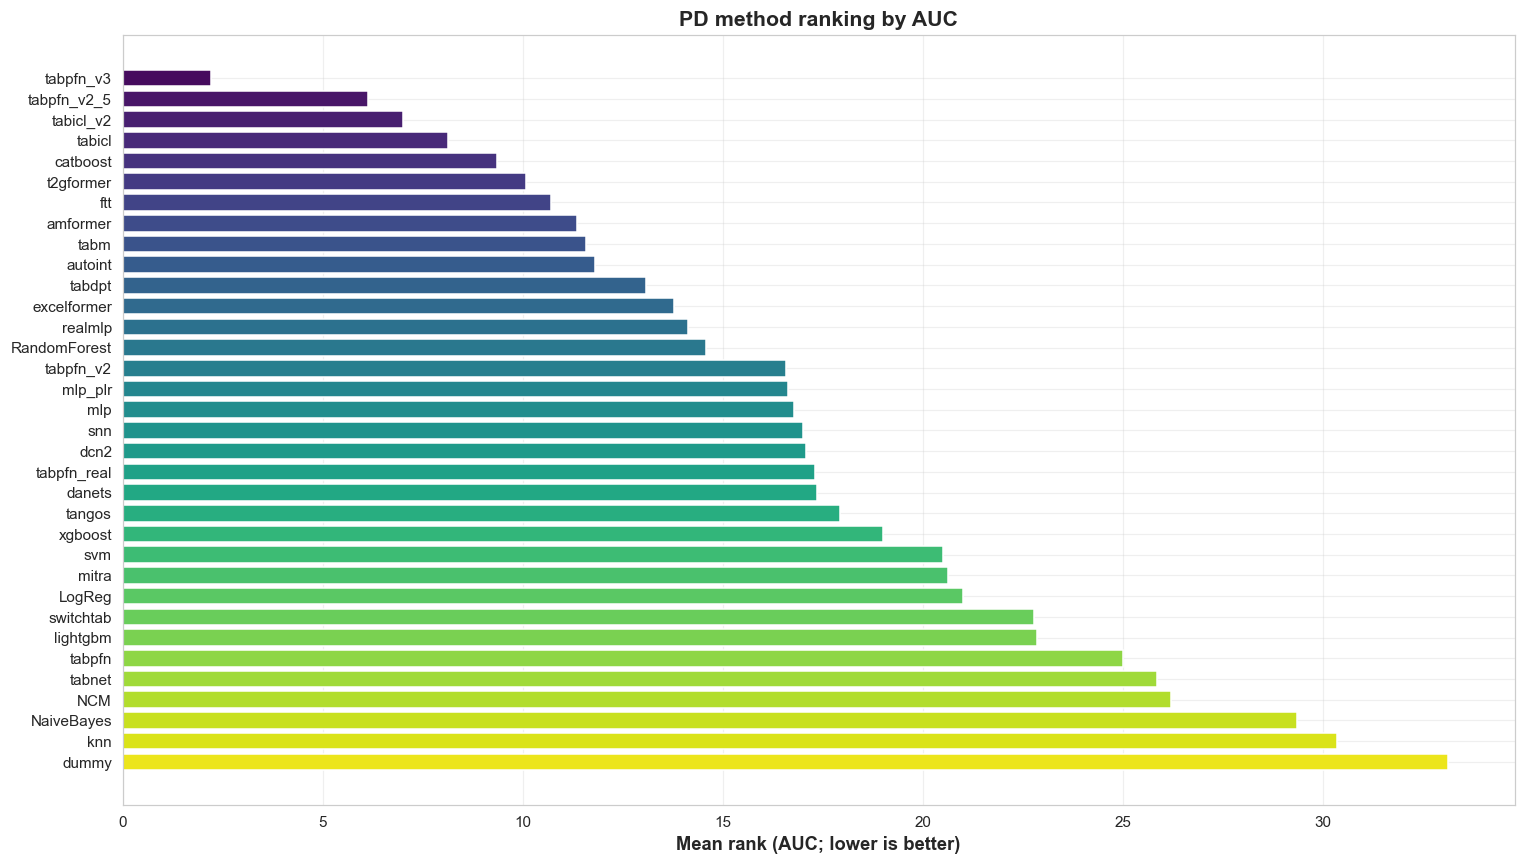

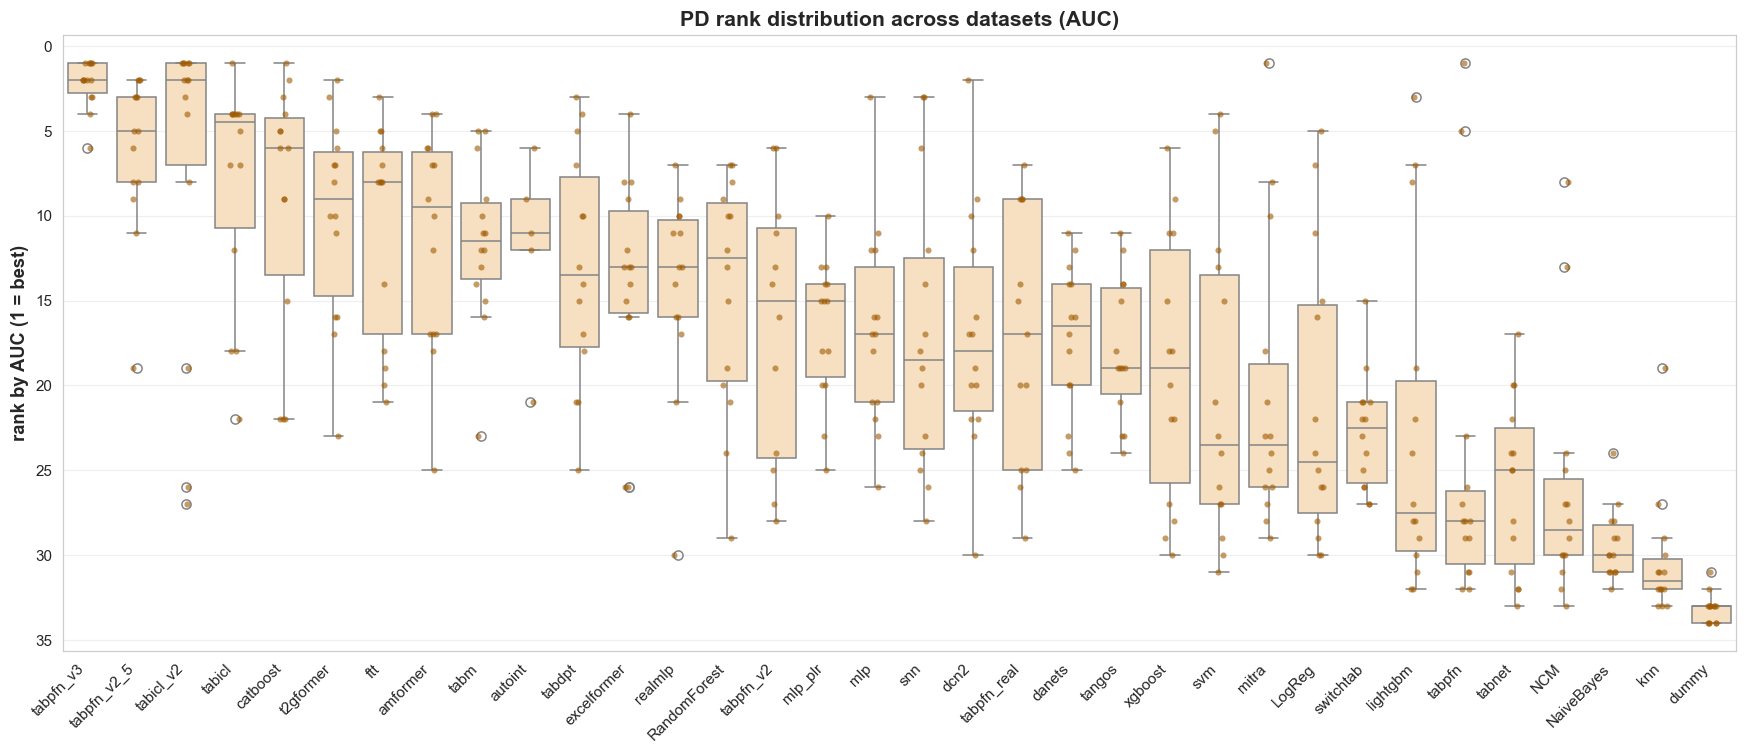

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_rank_box_auc.pdf')

In [7]:
rank_heatmap(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## Effect of hyper-parameter tuning on AUC
(foundation models are copies of their NO_HPO run → 0 by design)

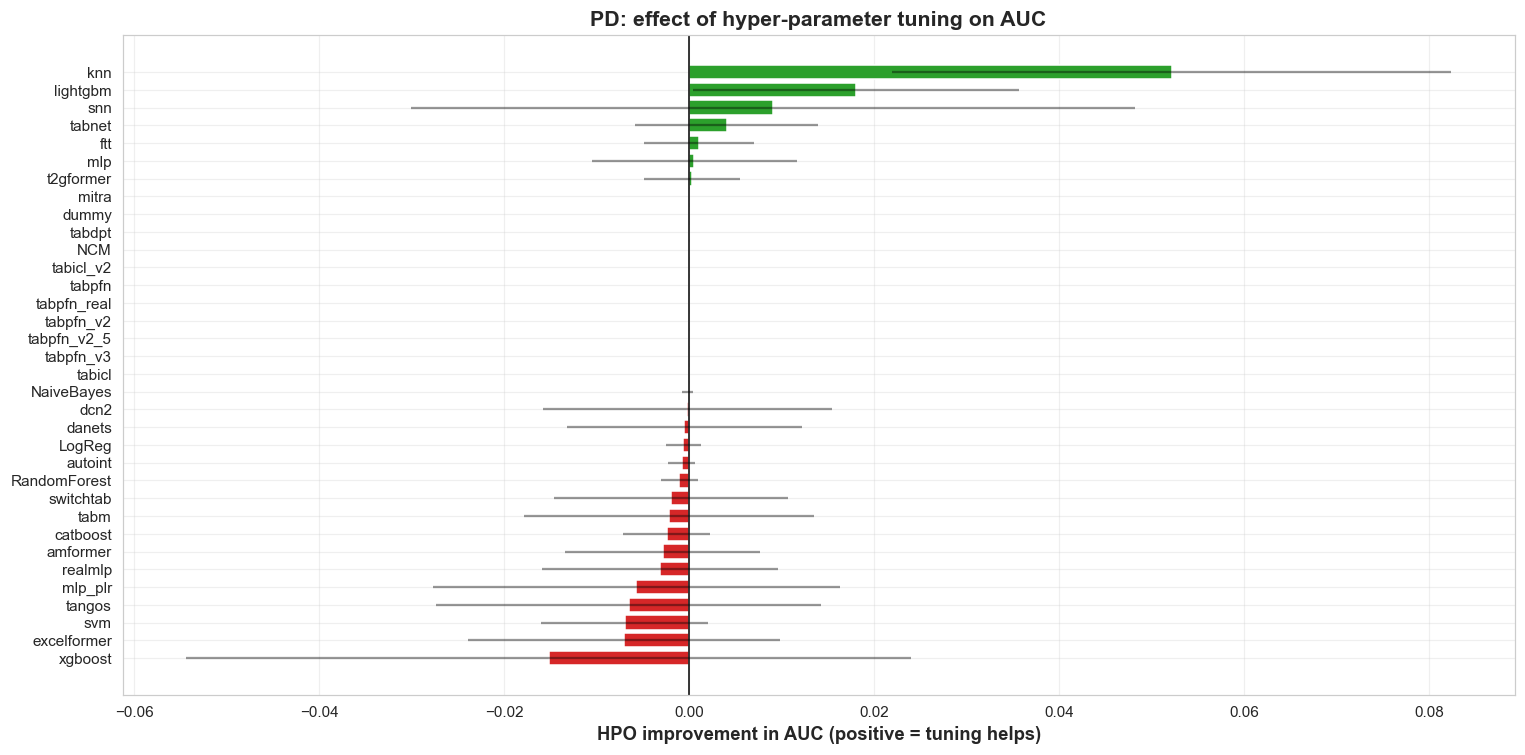

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_hpo_effect_auc.pdf')

In [8]:
hpo_improvement_bars(df_both, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## Performance vs training time

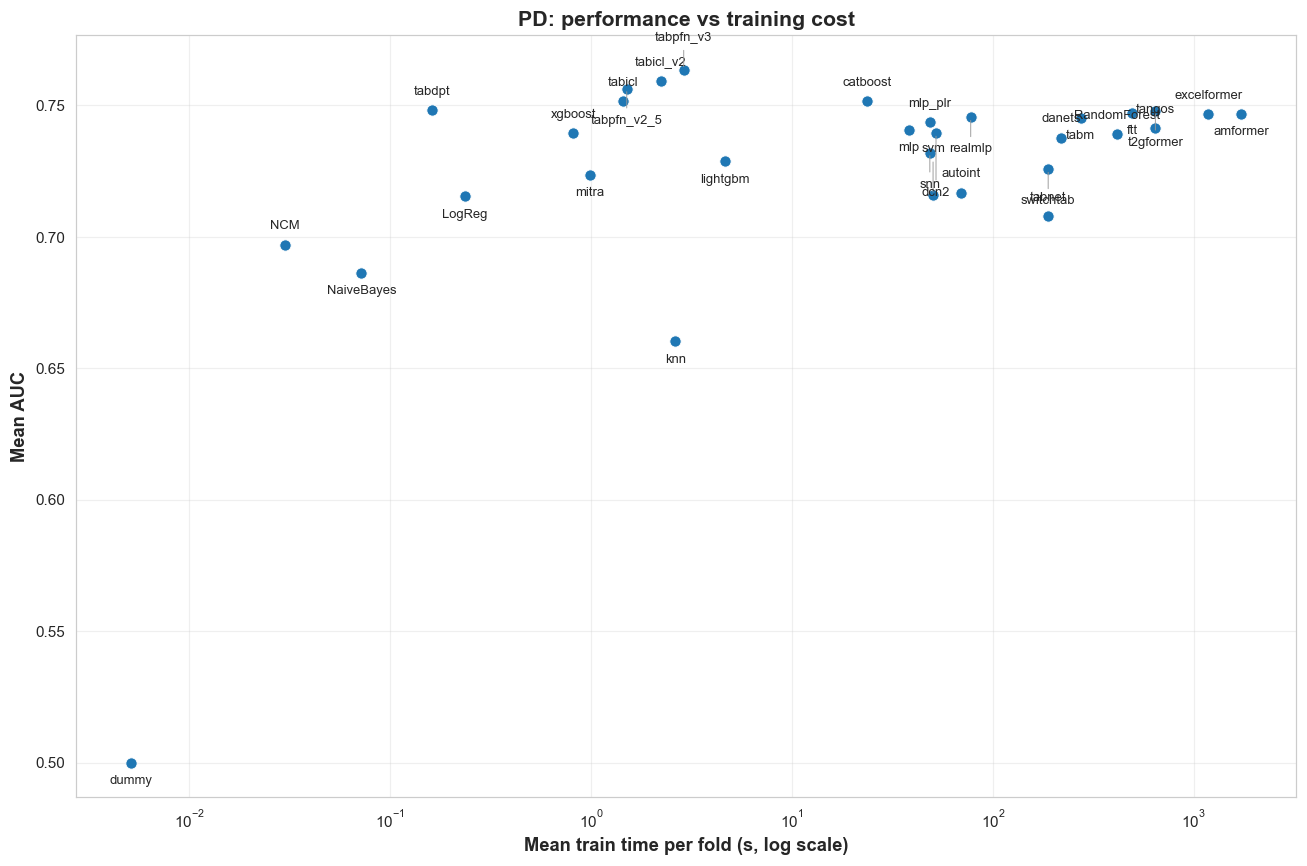

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_cost_quality_auc.pdf')

In [9]:
runtime_performance_scatter(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)